# Machine Learning - Midterm Exam 

This provides a comprehensive step-by-step flow for solving regression problem

### Authors
- Kimly John Vergara
- Daniel Mark Wiegand

### Instructor
**Joan Anfernee Bajar Ng**

--- 

##  Phase 1: Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np

# ── VISUALIZATION ─────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

# ── SETTINGS ──────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("successful installed")

successful installed


### 1.1 Data Inspection


In [ ]:
df = pd.read_csv('abalone.csv')

print(df.head())           # first 5 rows        
df.info()           # dtypes, non-null counts
df.shape            # (rows, cols)
print(df.dtypes)
df.nunique()
df.isnull().sum()


  sex  length  diameter  height  whole_weight  shucked_weight  viscera_weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   M   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   I   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   shell_weight  rings  
0         0.150     15  
1         0.070      7  
2         0.210      9  
3         0.155     10  
4         0.055      7  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sex             4177 non-null   object 
 1   length          4177 non-null   float64
 2   diameter        4177 non-null   float64
 3   height          4177 non-nu

sex               0
length            0
diameter          0
height            0
whole_weight      0
shucked_weight    0
viscera_weight    0
shell_weight      0
rings             0
dtype: int64

In [3]:
df.describe()     # mean, std, min, max, quartiles

,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


Upon inspection we have noticed that there is no null values but there is a value of height == 0, which does not make sense.

### 1.2 Data Cleaning
- **Duplicates**: Check and remove duplicate rows.
- **DropHeight equal to zero**: ensure there is no value of 0


In [4]:
df.drop_duplicates(inplace=True)
df["height"] = np.where((df["height"]) == 0, np.nan, df["height"])
df.dropna(inplace=True, axis=0)
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 4175 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sex             4175 non-null   object 
 1   length          4175 non-null   float64
 2   diameter        4175 non-null   float64
 3   height          4175 non-null   float64
 4   whole_weight    4175 non-null   float64
 5   shucked_weight  4175 non-null   float64
 6   viscera_weight  4175 non-null   float64
 7   shell_weight    4175 non-null   float64
 8   rings           4175 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 326.2+ KB


,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
count,4175.000000,4175.00000,4175.000000,4175.000000,4175.000000,4175.000000,4175.000000,4175.000000
mean,0.524065,0.40794,0.139583,0.829005,0.359476,0.180653,0.238834,9.935090
std,0.120069,0.09922,0.041725,0.490349,0.221954,0.109605,0.139212,3.224227
min,0.075000,0.05500,0.010000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.35000,0.115000,0.442250,0.186250,0.093500,0.130000,8.000000
50%,0.545000,0.42500,0.140000,0.800000,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.48000,0.165000,1.153500,0.502000,0.253000,0.328750,11.000000
max,0.815000,0.65000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


### 1.3 Outlier Detection & Handling
- Outliers heavily impact distance-based and linear regression models.
- **Visuals**: Use boxplots to visualize extreme outliers.
- **IQR Method**: Calculate Q1, Q3, and IQR to identify bounds.


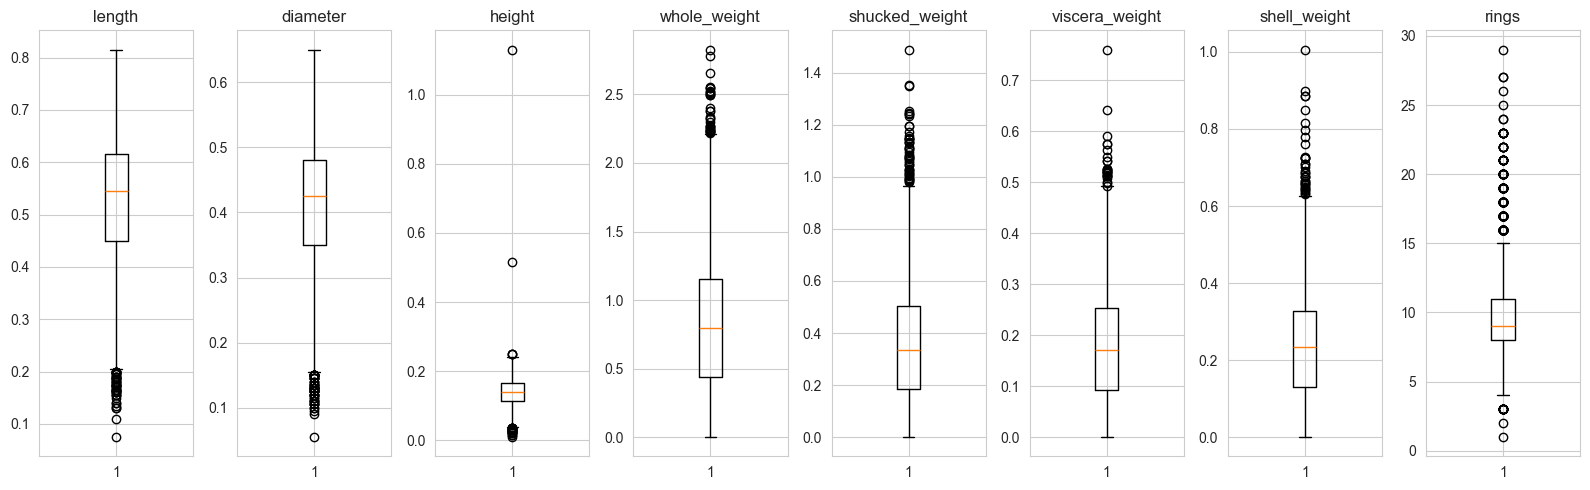

In [5]:
numerical_cols = df.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(16, 5))
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
plt.tight_layout()
plt.show()



We have noticed that the height has a very low IQR. the rings (target variable) contains a bit of outliers which could affect the model's performance. weights also contained outliers, we have removed only those of the whole_weight because it is already the total of all weights

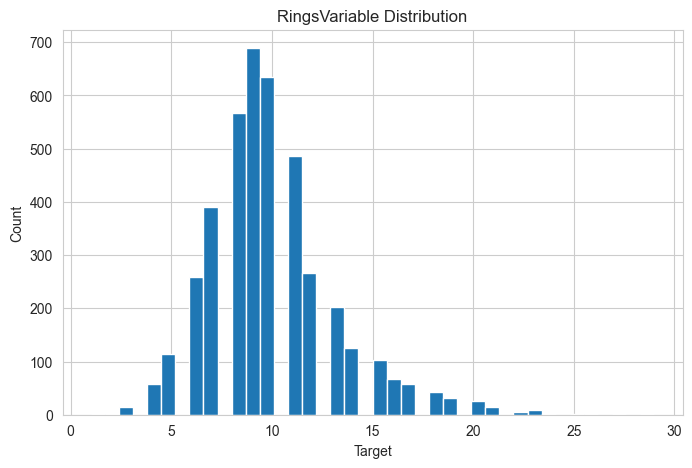

Outliers in rings: 278


In [6]:
plt.figure(figsize=(8, 5))
df['rings'].hist(bins=40)
plt.title('RingsVariable Distribution')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

Q1  = df['rings'].quantile(0.25)
Q3  = df['rings'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Check how many outliers
outliers = df[(df['rings'] < lower) | (df['rings'] > upper)]
print(f"Outliers in rings: {len(outliers)}")

# Remove outliers
df = df[(df['rings'] >= lower) & (df['rings'] <= upper)]

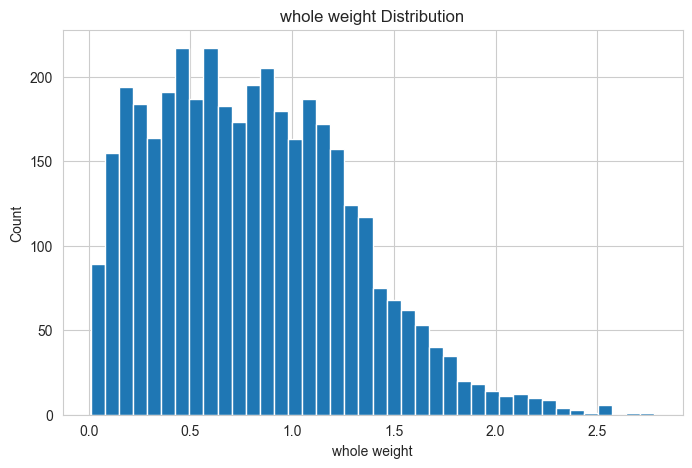

Outliers in whole_weight: 31


In [7]:
plt.figure(figsize=(8, 5))
df['whole_weight'].hist(bins=40)
plt.title('whole weight Distribution')
plt.xlabel('whole weight')
plt.ylabel('Count')
plt.show()

Q1  = df['whole_weight'].quantile(0.25)
Q3  = df['whole_weight'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Check how many outliers
outliers = df[(df['whole_weight'] < lower) | (df['whole_weight'] > upper)]
print(f"Outliers in whole_weight: {len(outliers)}")

# Remove them (optional — justify in your insight!)
df = df[(df['whole_weight'] >= lower) & (df['whole_weight'] <= upper)]

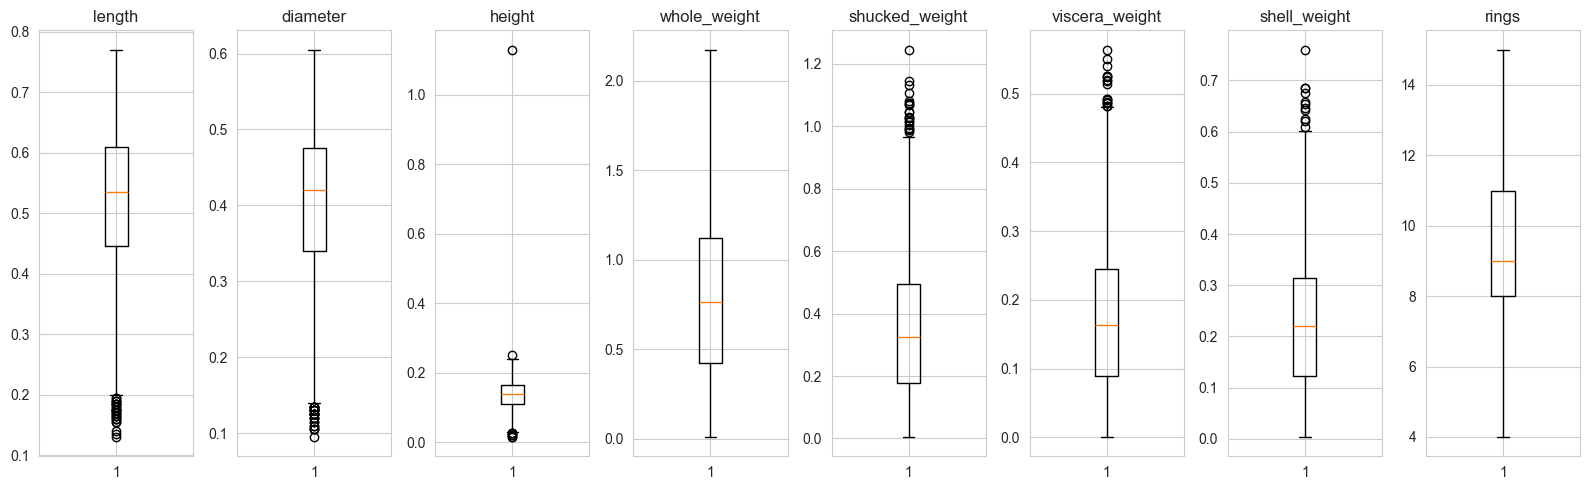

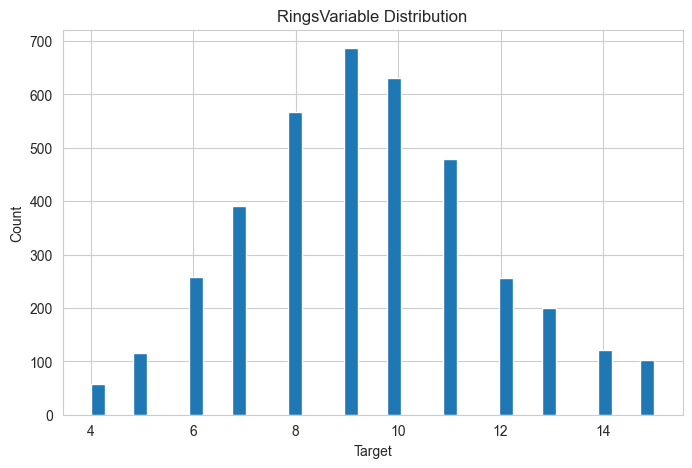

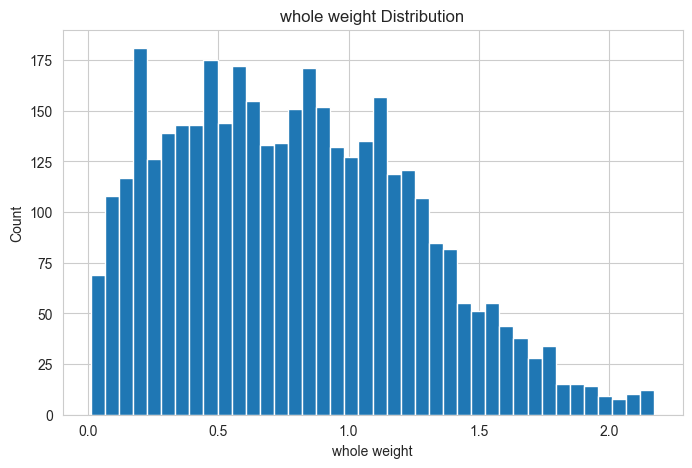

In [8]:
numerical_cols = df.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(16, 5))
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
df['rings'].hist(bins=40)
plt.title('RingsVariable Distribution')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 5))
df['whole_weight'].hist(bins=40)
plt.title('whole weight Distribution')
plt.xlabel('whole weight')
plt.ylabel('Count')
plt.show()



these are the values after removing the outliers of rings and whole_weight. the target variable (rings) also now has a better bell curved shape

### 1.4 Feature Engineering
- **Transformations**: Log-transform highly skewed features
- **Domain Features**:  Ratio features
- **Encoding Targets**: One hot encoding for sex

In [9]:
# Check skewness first
for col in df.select_dtypes(include=np.number).columns:
    skew = df[col].skew()
    if abs(skew) > 1.5 and df[col].min() >= 0:
        df[col] = np.log1p(df[col])   # log1p = log(x+1), safe when x=0
        print(f"Log-transformed: {col} (was skew={skew:.2f})")

Log-transformed: height (was skew=3.68)


In [10]:
df["body_volume"] = df["length"] * df["diameter"] * df["height"]
df["shell_weight_to_whole_weight"] = df["shell_weight"] / df["whole_weight"]
df["viscera_weight_to_whole_weight"] = df["viscera_weight"] / df["whole_weight"]
df["shucked_weight_to_whole_weight"] = df["shucked_weight"] / df["whole_weight"]

df.drop(columns=["viscera_weight", "shell_weight", "shucked_weight"], inplace=True)
df.head()

,sex,length,diameter,height,whole_weight,rings,body_volume,shell_weight_to_whole_weight,viscera_weight_to_whole_weight,shucked_weight_to_whole_weight
0,M,0.455,0.365,0.090754,0.5140,15,0.015072,0.291829,0.196498,0.436770
1,M,0.350,0.265,0.086178,0.2255,7,0.007993,0.310421,0.215078,0.441242
2,F,0.530,0.420,0.126633,0.6770,9,0.028188,0.310192,0.209010,0.378877
3,M,0.440,0.365,0.117783,0.5160,10,0.018916,0.300388,0.220930,0.417636
4,I,0.330,0.255,0.076961,0.2050,7,0.006476,0.268293,0.192683,0.436585


### 1.5 Visualization


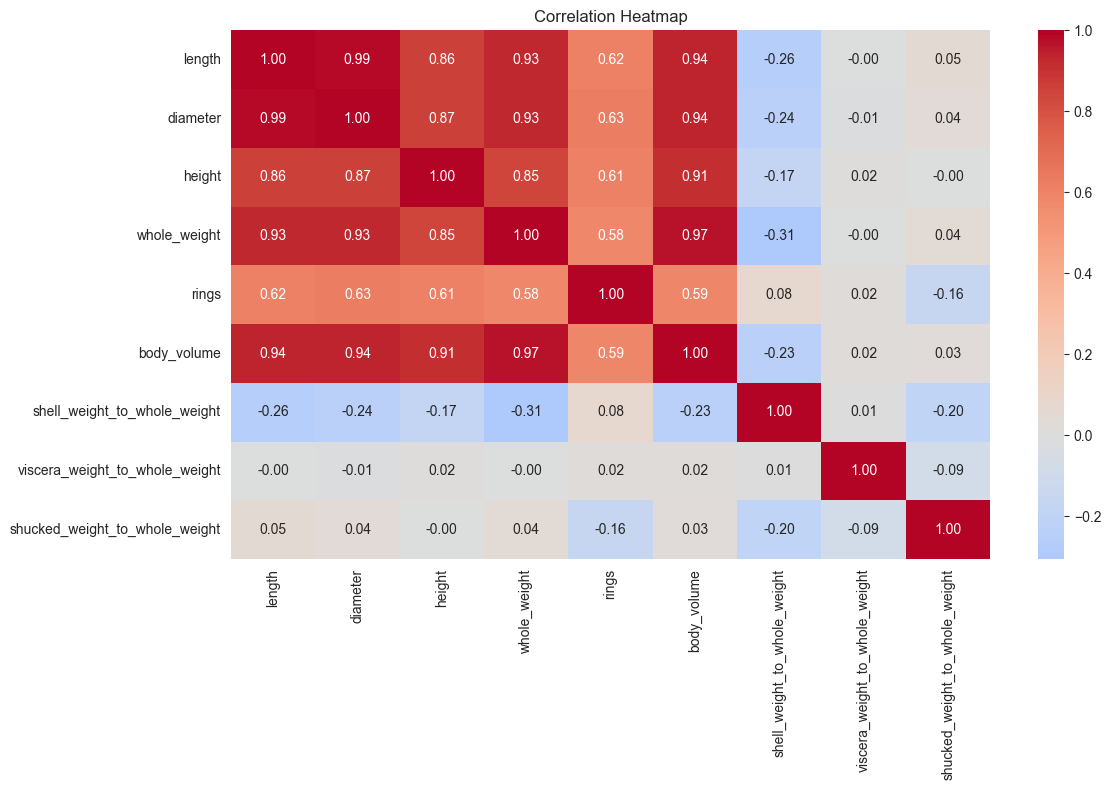

In [11]:
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

we have noticed that the body_volume correlated storngly with the rings. this make sense because the older the abalone the bigger it is.



## Phase 2: Preprocessing

### 2.1 Categorical Encoding


In [12]:
sex_dummies =  pd.get_dummies(df['sex'], drop_first=False).astype(int)
df.drop(columns=["sex"], inplace=True)
df = pd.concat([df, sex_dummies], axis=1)
df.head()

,length,diameter,height,whole_weight,rings,body_volume,shell_weight_to_whole_weight,viscera_weight_to_whole_weight,shucked_weight_to_whole_weight,F,I,M
0,0.455,0.365,0.090754,0.5140,15,0.015072,0.291829,0.196498,0.436770,0,0,1
1,0.350,0.265,0.086178,0.2255,7,0.007993,0.310421,0.215078,0.441242,0,0,1
2,0.530,0.420,0.126633,0.6770,9,0.028188,0.310192,0.209010,0.378877,1,0,0
3,0.440,0.365,0.117783,0.5160,10,0.018916,0.300388,0.220930,0.417636,0,0,1
4,0.330,0.255,0.076961,0.2050,7,0.006476,0.268293,0.192683,0.436585,0,1,0


used one hot encoding for sex category

### 2.2 Train-Test Split
- Split the dataset into `X` (features) and `y` (target).


In [13]:
# ── PREPROCESSING ─────────────────────────────────────────
from sklearn.model_selection import train_test_split

X = df.drop('rings', axis=1)
y = df['rings']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      
    random_state=42      
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (3092, 11)
Test size:  (774, 11)


### 2.3 Feature Scaling
- normalize values

In [14]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 3866 entries, 0 to 4176
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   length                          3866 non-null   float64
 1   diameter                        3866 non-null   float64
 2   height                          3866 non-null   float64
 3   whole_weight                    3866 non-null   float64
 4   rings                           3866 non-null   int64  
 5   body_volume                     3866 non-null   float64
 6   shell_weight_to_whole_weight    3866 non-null   float64
 7   viscera_weight_to_whole_weight  3866 non-null   float64
 8   shucked_weight_to_whole_weight  3866 non-null   float64
 9   F                               3866 non-null   int64  
 10  I                               3866 non-null   int64  
 11  M                               3866 non-null   int64  
dtypes: float64(8), int64(4)
memory usage: 3



##  Phase 3: Model Training


1. **Linear Models**:
   - `LinearRegression`: Good baseline.
   - `Ridge` (L2 penalty) / `Lasso` (L1 penalty): Useful when features are correlated.
2. **Distance-Based**:
   - `KNeighborsRegressor` (KNN)
3. **Tree-Based / Ensemble**:
   - `DecisionTreeRegressor`
   - `RandomForestRegressor`


In [15]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Linear Regression R²:  ", r2_score(y_test, y_pred_lr))

Linear Regression RMSE: 1.6378641314404736
Linear Regression R²:   0.5219351088651492


In [16]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)   # alpha = regularization strength
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("Ridge R²:  ", r2_score(y_test, y_pred_ridge))

Ridge RMSE: 1.6379931654267836
Ridge R²:   0.5218597802132454


In [17]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("Lasso R²:  ", r2_score(y_test, y_pred_lasso))

Lasso RMSE: 1.6542545246118117
Lasso R²:   0.5123190755880428


In [18]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42, max_depth=5)
dt.fit(X_train, y_train)    # Note: Prof used UNSCALED data here
y_pred_dt = dt.predict(X_test)

print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("Decision Tree R²:  ", r2_score(y_test, y_pred_dt))

Decision Tree RMSE: 1.573817418793628
Decision Tree R²:   0.5585924048766749


In [19]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("KNN RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_knn)))
print("KNN R²:  ", r2_score(y_test, y_pred_knn))

KNN RMSE: 1.6240639506056422
KNN R²:   0.5299572493874811


In [20]:
from sklearn.ensemble import RandomForestRegressor 

dt = RandomForestRegressor(random_state=42, max_depth=5)
dt.fit(X_train, y_train)    # Note: Prof used UNSCALED data here
y_pred_dt = dt.predict(X_test)

print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("Decision Tree R²:  ", r2_score(y_test, y_pred_dt))

Decision Tree RMSE: 1.515551475850211
Decision Tree R²:   0.5906710232508531




## Phase 4: Hyperparameter Tuning

Improving the best-performing model (random forest) by exploring hyperparameter its spaces


In [21]:
basemodel = dt

from sklearn.model_selection import GridSearchCV



param_grid = {
    'n_estimators':    [50, 100, 200],
    'max_depth':       [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
# Total combinations: 3 × 4 × 3 = 36 combos × 5 folds = 180 fits

# Step 2: Create GridSearchCV
grid_search = GridSearchCV(
    estimator  = RandomForestRegressor(random_state=42),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'neg_mean_squared_error',   
    n_jobs     = -1,     # use all CPU cores (faster)
    verbose    = 1       # shows progress
)

# Step 3: Fit (this trains ALL combinations)
grid_search.fit(X_train, y_train)

# Step 4: Get results
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:  ", np.sqrt(-grid_search.best_score_))  # convert for RMSE

# Step 5: Get best model (already trained with best params)
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Best CV Score:   1.567693381449851



## Phase 5: Model Evaluation & Comparison

Unlike classification, regression relies on calculating the difference between the actual and predicted quantities.

- **RMSE (Root Mean Squared Error)**: The standard metric; penalizes larger errors. Lower is better.
- **MAE (Mean Absolute Error)**: Less sensitive to large outliers, representing absolute "off-by" amount.
- **R2 score**: Explains the percentage of variance (0 no better thab the mean), 1.0 perfect


RandomForestRegressor(max_depth=10, min_samples_split=10, n_estimators=200,
                      random_state=42)
Validation MAE:  1.16
Validation RMSE: 1.53
Validation R2 0.58


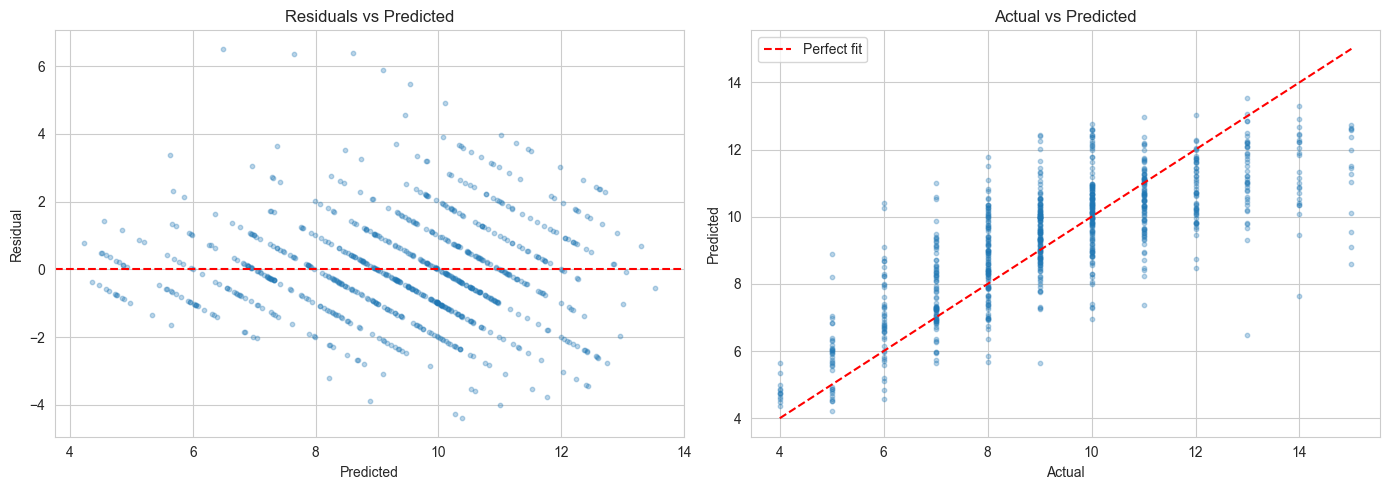

In [22]:
print(best_model)
val_preds = best_model.predict(X_test)
mae  = mean_absolute_error(y_test, val_preds)
rmse = root_mean_squared_error(y_test, val_preds)
r2 = r2_score(y_test,val_preds)

print(f"Validation MAE:  {mae:,.2f}")
print(f"Validation RMSE: {rmse:,.2f}")
print(f"Validation R2 {r2:,.2f}")
fig, axes = plt.subplots(1, 2,  figsize=(14, 5))

# Residuals plot
residuals = y_test - val_preds
axes[0].scatter(val_preds, residuals, alpha=0.3, s=10)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

# Actual vs Predicted plot
axes[1].scatter(y_test, val_preds, alpha=0.3, s=10)
min_val = min(y_test.min(), val_preds.min())
max_val = max(y_test.max(), val_preds.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect fit")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")
axes[1].set_title("Actual vs Predicted")
axes[1].legend()

plt.tight_layout()
plt.show()


as we can see the best model (random forest) has decent metrics, it can handle small to medium values but struggles with the larger ones.